# Modelo LDR
$$G=AE^\gamma$$

- $G$: conductancia
- $E$: idealmente iluminancia. En este caso es la intensidad relativa de cada LED
    - $E = c \in [0,255]$
- $A,\,\gamma$: variables

# Resolución por minimización de cuadrados

Se toman $n$ medidas de la conductancia $G$ a intensidades $c$ conocidas para cada color.

$$
Y = 
\begin{bmatrix}
G_1 \\
G_2 \\
\vdots \\
G_N
\end{bmatrix}
\qquad
A = 
\begin{bmatrix}
1 & \ln(c_1) \\
1 & \ln(c_2) \\
1 & \ln(c_N) \\
\end{bmatrix}
\qquad
\beta = 
\begin{bmatrix}
\alpha_1 \\
\alpha_2 \\
\vdots \\
\alpha_M \\
\end{bmatrix}
$$


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
Vref = 3.3
Vdd = 5

In [4]:
dfR = pd.read_json("measurements_R.json").set_index("index")
dfR = dfR.drop("data", axis="columns")
dfR = dfR.rename(columns={"mean": "adc"})
dfR.tail()

,channel,intensity,adc,Rf
index,,,,
36,R,159,2340.350,1
37,R,178,2234.325,1
38,R,201,2110.500,1
39,R,226,2005.925,1
40,R,255,1882.525,1


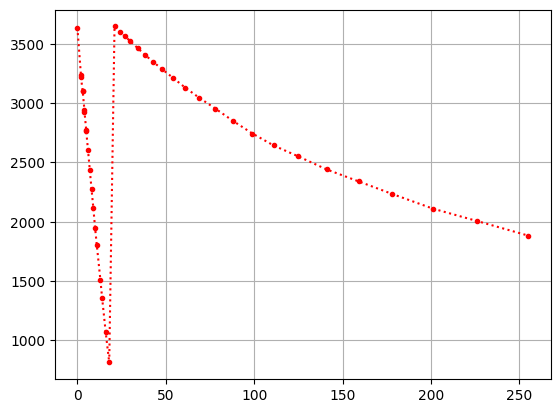

In [5]:
plt.plot("intensity", "adc", data=dfR, marker=".", linestyle="dotted", color="red")
plt.grid()

In [6]:
dfR["Vo"] = dfR["adc"] * Vref / 4095 
dfR.head()

,channel,intensity,adc,Rf,Vo
index,,,,,
0,R,0,3637.450,10,2.931278
1,R,2,3238.700,10,2.609941
2,R,2,3220.375,10,2.595174
3,R,3,3101.525,10,2.499397
4,R,3,3098.650,10,2.497081


In [7]:
dfR["G"] = (Vref - dfR["Vo"]) / (dfR["Rf"]*(Vdd-Vref))
dfR.tail(10)

,channel,intensity,adc,Rf,Vo,G
index,,,,,,
31,R,88,2850.275,1,2.296925,0.590044
32,R,99,2743.975,1,2.211262,0.640434
33,R,111,2642.900,1,2.129810,0.688347
34,R,125,2550.350,1,2.055227,0.732219
35,R,141,2440.800,1,1.966945,0.784150
36,R,159,2340.350,1,1.885996,0.831767
37,R,178,2234.325,1,1.800555,0.882027
38,R,201,2110.500,1,1.700769,0.940724
39,R,226,2005.925,1,1.616496,0.990296


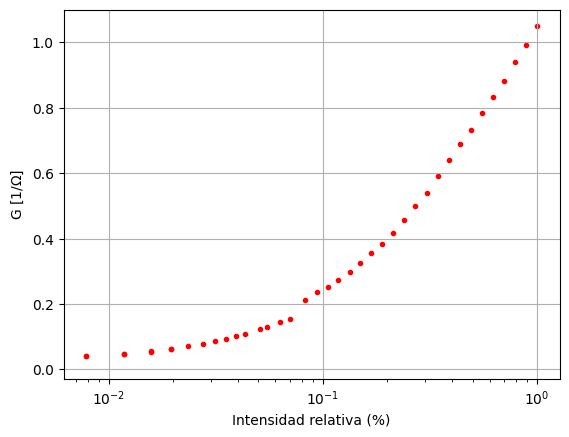

In [8]:
plt.scatter(dfR["intensity"]/255, dfR["G"], marker=".", color="red")
plt.xscale('log')
plt.ylabel(r"G $[1/\Omega]$")
plt.xlabel("Intensidad relativa (%)")
plt.grid()

In [9]:
# least squares
# b = Ax
b, c = (
    np.log(dfR.loc[dfR["intensity"] > 0, "G"]),
    dfR.loc[dfR["intensity"] > 0, "intensity"]
)

A = np.column_stack((np.ones(len(c)), np.log(c)))
A.shape

(40, 2)

In [10]:
x = np.linalg.lstsq(A, b)[0]
x

array([-3.88229728,  0.73486128])

In [11]:
Ka_R = np.exp(x[0])
gamma_R = x[1]

Ka_R, gamma_R

(np.float64(0.020603438911895946), np.float64(0.7348612801250921))

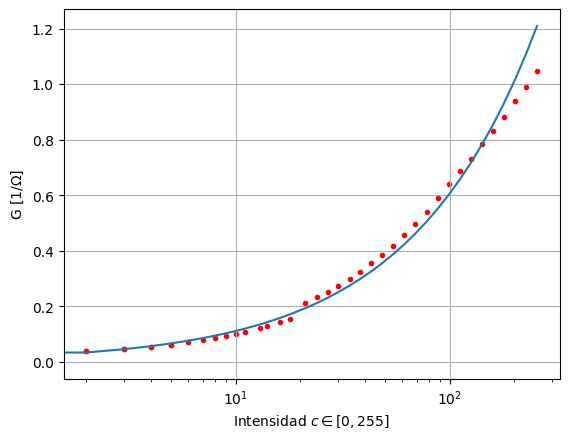

In [12]:
plt.scatter(dfR["intensity"], dfR["G"], marker=".", color="red")
plt.xscale('log')

plt.semilogx(dfR["intensity"], Ka_R*np.pow(dfR["intensity"], gamma_R))

plt.ylabel(r"G $[1/\Omega]$")
plt.xlabel(r"Intensidad $c \in [0,255]$")
plt.grid()

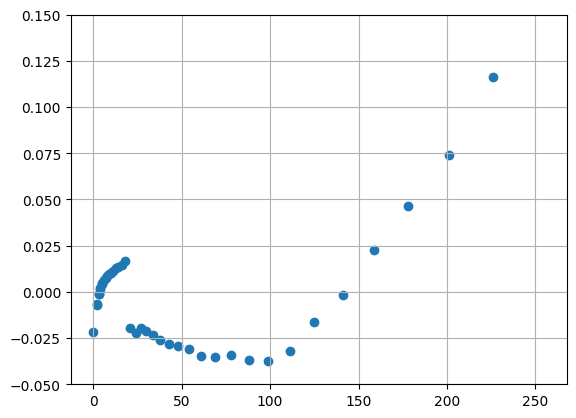

In [16]:
estimate = Ka_R*np.pow(dfR["intensity"], gamma_R)

plt.scatter(dfR["intensity"], estimate-dfR["G"])

plt.ylim((-0.05, 0.15))
plt.grid()

# Canal G

In [85]:
dfG = pd.read_json("measurements_G.json").set_index("index")
dfG = dfG.drop("data", axis="columns")
dfG = dfG.rename(columns={"mean": "adc"})
dfG.tail()

,channel,intensity,adc,Rf
index,,,,
32,G,159,3475.825,1
33,G,178,3432.700,1
34,G,201,3388.750,1
35,G,226,3341.750,1
36,G,255,3292.075,1


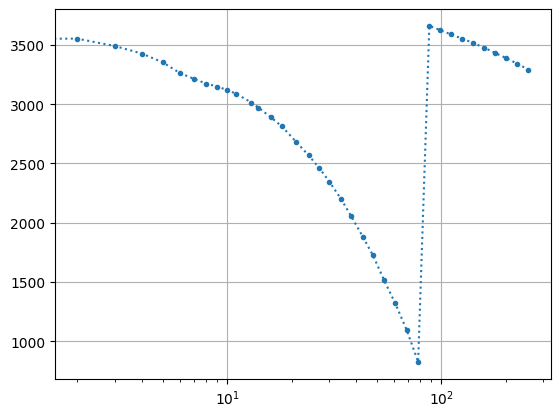

In [89]:
plt.plot("intensity", "adc", data=dfG, marker=".", linestyle="dotted")
plt.grid()
plt.xscale('log')

In [90]:
dfG["Vo"] = dfG["adc"] * Vref / 4095 
dfG["G"] = (Vref - dfG["Vo"]) / (dfG["Rf"]*(Vdd-Vref))
dfG.tail()

,channel,intensity,adc,Rf,Vo,G
index,,,,,,
32,G,159,3475.825,1,2.801031,0.293511
33,G,178,3432.700,1,2.766278,0.313954
34,G,201,3388.750,1,2.730861,0.334788
35,G,226,3341.750,1,2.692985,0.357067
36,G,255,3292.075,1,2.652954,0.380615


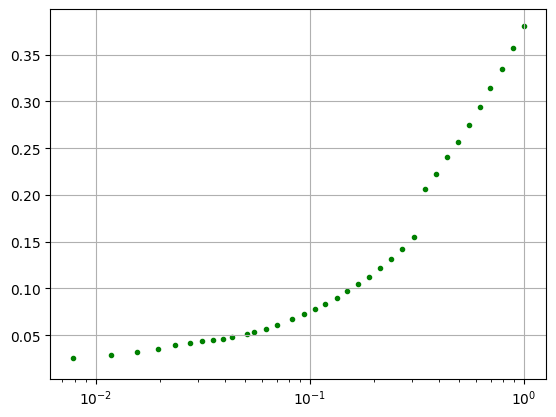

In [91]:
plt.scatter(dfG["intensity"]/255, dfG["G"], marker=".", color="green")
plt.xscale("log")
plt.grid()

In [92]:
# least squares
# b = Ax
b, c = (
    np.log(dfG.loc[dfG["intensity"] > 0, "G"]),
    dfG.loc[dfG["intensity"] > 0, "intensity"]
)

A = np.column_stack((np.ones(len(c)), np.log(c)))
A.shape

(36, 2)

In [93]:
x = np.linalg.lstsq(A, b)[0]
x

array([-4.41107295,  0.60494757])

In [94]:
Ka_G = np.exp(x[0])
gamma_G = x[1]

Ka_G, gamma_G

(np.float64(0.012142143449443102), np.float64(0.604947571455075))

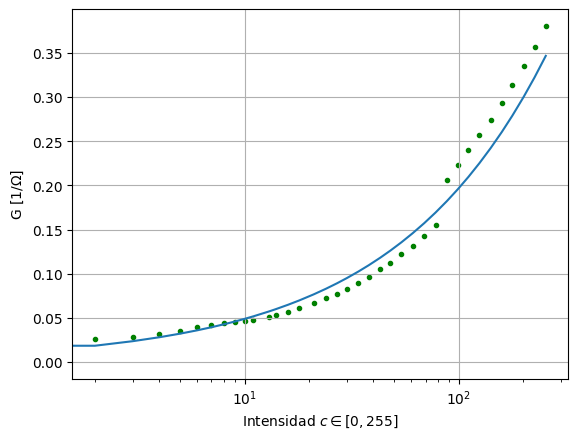

In [95]:
plt.scatter(dfG["intensity"], dfG["G"], marker=".", color="green")
plt.xscale('log')

plt.semilogx(dfG["intensity"], Ka_G*np.pow(dfG["intensity"], gamma_G))

plt.ylabel(r"G $[1/\Omega]$")
plt.xlabel(r"Intensidad $c \in [0,255]$")
plt.grid()

# Canal B

In [ ]:
dfB = pd.read_json("measurements_B.json").set_index("index")
dfB = dfB.drop("data", axis="columns")
dfB = dfB.rename(columns={"mean": "adc"})
dfB.tail()

,channel,intensity,adc,Rf
index,,,,
32,B,159,3559.550,1
33,B,178,3527.350,1
34,B,201,3487.450,1
35,B,226,3451.950,1
36,B,255,3409.175,1


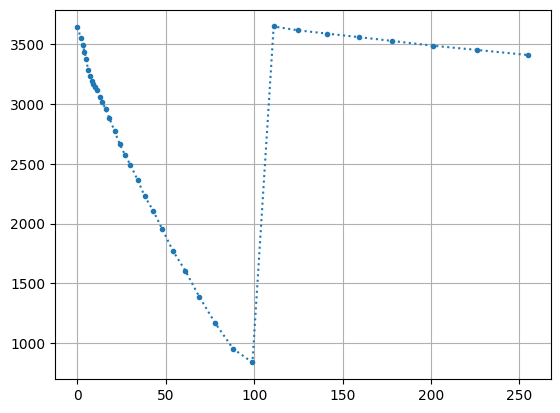

In [78]:
plt.plot("intensity", "adc", data=dfB, marker=".", linestyle="dotted")
plt.grid()

In [79]:
dfB["Vo"] = dfB["adc"] * Vref / 4095 
dfB["G"] = (Vref - dfB["Vo"]) / (dfB["Rf"]*(Vdd-Vref))
dfB.tail()

,channel,intensity,adc,Rf,Vo,G
index,,,,,,
32,B,159,3559.550,1,2.868502,0.253822
33,B,178,3527.350,1,2.842553,0.269086
34,B,201,3487.450,1,2.810399,0.288000
35,B,226,3451.950,1,2.781791,0.304829
36,B,255,3409.175,1,2.747321,0.325106


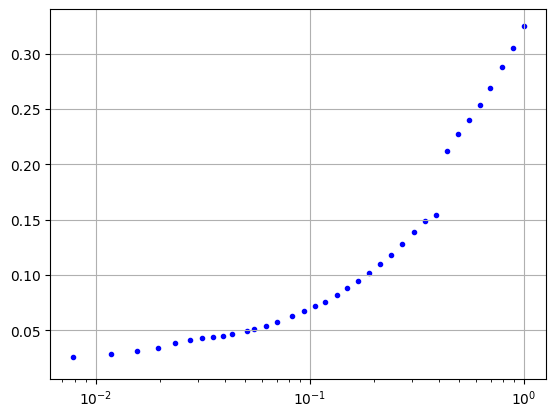

In [80]:
plt.scatter(dfB["intensity"]/255, dfB["G"], marker=".", color="blue")
plt.xscale("log")
plt.grid()

In [81]:
# least squares
# b = Ax
b, c = (
    np.log(dfB.loc[dfB["intensity"] > 0, "G"]),
    dfB.loc[dfB["intensity"] > 0, "intensity"]
)

A = np.column_stack((np.ones(len(c)), np.log(c)))
A.shape

(36, 2)

In [82]:
x = np.linalg.lstsq(A, b)[0]
x

array([-4.35274917,  0.56069763])

In [83]:
Ka_B = np.exp(x[0])
gamma_B = x[1]

Ka_B, gamma_B

(np.float64(0.01287137832731499), np.float64(0.5606976305078668))

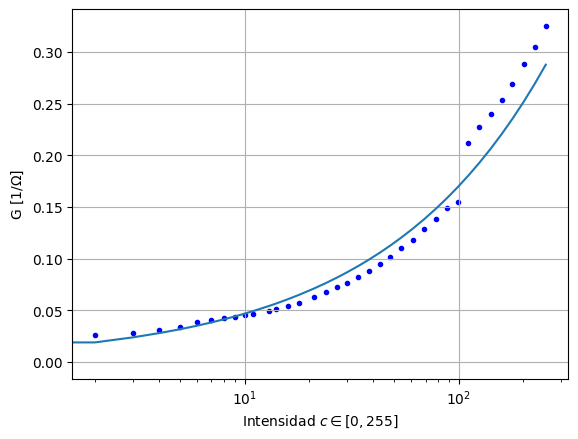

In [84]:
plt.scatter(dfB["intensity"], dfB["G"], marker=".", color="blue")
plt.xscale('log')

plt.semilogx(dfB["intensity"], Ka_B*np.pow(dfB["intensity"], gamma_B))

plt.ylabel(r"G $[1/\Omega]$")
plt.xlabel(r"Intensidad $c \in [0,255]$")
plt.grid()